In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
df = pd.read_csv("..\\raw_datasets\\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

(7043, 21)

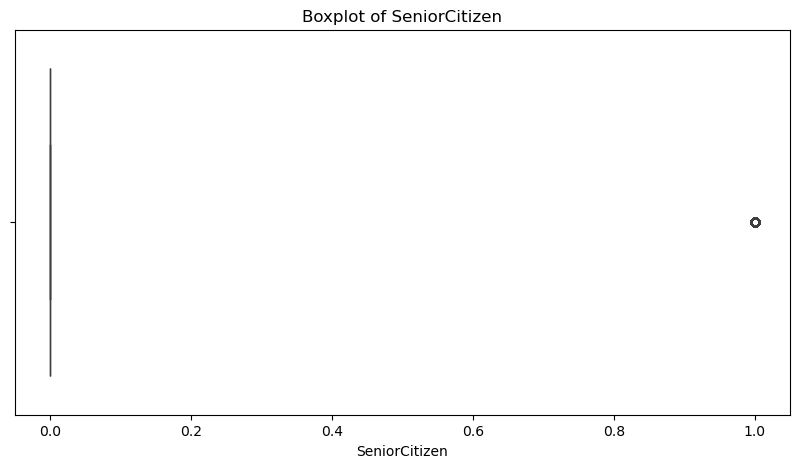

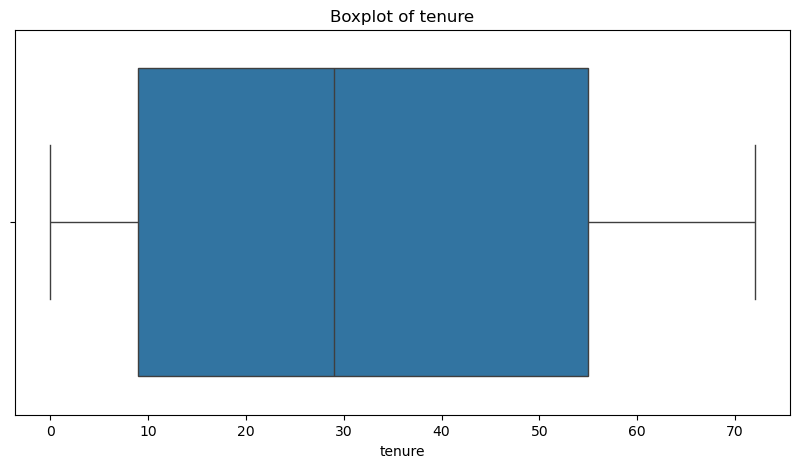

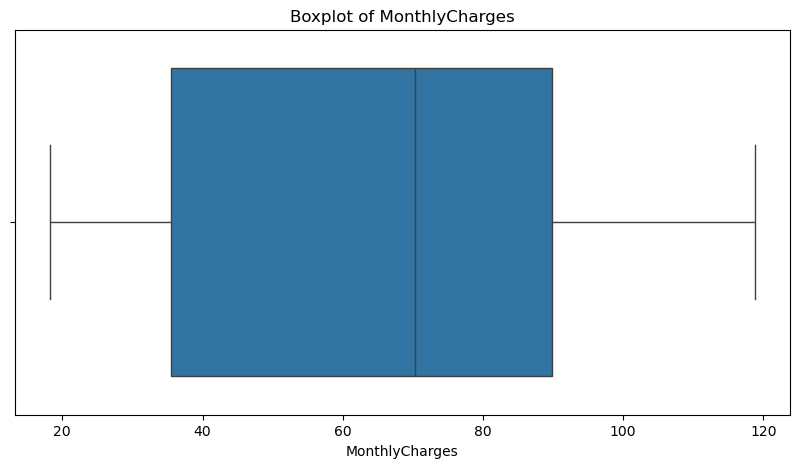

In [ ]:
#detect outliers
for column in df.select_dtypes(include=[np.number]).columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot of {column}')
    plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [ ]:
features = [
'tenure',
'Contract',
'MonthlyCharges',
'PaymentMethod',
'InternetService',
'TechSupport',
]

In [ ]:
data = df[features + ['Churn']]
data.to_csv('..\\processed_datasets\\subscription_renewal_data.csv', index=False)
target = df['Churn']

In [ ]:
data.head()

,tenure,Contract,MonthlyCharges,PaymentMethod,InternetService,TechSupport,Churn
0,1,Month-to-month,29.85,Electronic check,DSL,No,No
1,34,One year,56.95,Mailed check,DSL,No,No
2,2,Month-to-month,53.85,Mailed check,DSL,No,Yes
3,45,One year,42.30,Bank transfer (automatic),DSL,Yes,No
4,2,Month-to-month,70.70,Electronic check,Fiber optic,No,Yes


In [ ]:
encoders = {}

for col in df.select_dtypes(include=['object']).columns:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col].astype(str))
    encoders[col] = encoder

In [ ]:
X = df[features]

y = df['Churn']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Handle missing values in TotalCharges
X_train_clean = X_train.copy()
X_test_clean = X_test.copy()

# Scale features for better performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

print("Data preprocessing completed")

Data preprocessing completed


In [ ]:
# Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)

lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("\n=== Logistic Regression Results ===")
print(f"Accuracy: {accuracy_lr:.4f}")


=== Logistic Regression Results ===
Accuracy: 1.0000


In [ ]:
# prediction
new_data = pd.DataFrame({
    'tenure': [2],
    'Contract': ['Month-to-month'],
    'MonthlyCharges': [70.70],
    'PaymentMethod': ['Electronic check'],
    'InternetService': ['Fiber optic'],
    'TechSupport': ['No']
})

for col in ['Contract', 'PaymentMethod', 'InternetService', 'TechSupport']:
    new_data[col] = encoders[col].transform(new_data[col].astype(str))

new_data_scaled = scaler.transform(new_data)
prediction = lr_model.predict(new_data_scaled)
print(f"\nPrediction for new data: {'Churn' if prediction[0] == 1 else 'No Churn'}")

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- Churn
